In [2]:
import pandas as pd
import numpy as np

data = {
    'Population': [10000, 15000, 20000, 9000, 12000],
    'YearsInBusiness': [5, 6, 6, 5, 4],
    'Profit': [10000, 12000, 13000, 12000, np.nan]  # last row is what we predict
}
df = pd.DataFrame(data)
df.to_csv('food_truck_data.csv', index=False)
df


,Population,YearsInBusiness,Profit
0,10000,5,10000.0
1,15000,6,12000.0
2,20000,6,13000.0
3,9000,5,12000.0
4,12000,4,NaN


In [3]:
train = df.dropna()
X = train['Population'].values
y = train['Profit'].values

# --- Normal Equation: theta = (X^T X)^-1 X^T y ---
X_b = np.c_[np.ones(len(X)), X]   # add bias column
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("Normal Equation coeffs (intercept, slope):", theta_normal)

Normal Equation coeffs (intercept, slope): [9.38311688e+03 1.75324675e-01]


In [4]:
X_mean, X_std = X.mean(), X.std()
X_norm = (X - X_mean) / X_std

theta0, theta1 = 0, 0
lr = 0.01
epochs = 1000
m = len(X)

for _ in range(epochs):
    y_pred = theta0 + theta1 * X_norm
    error = y_pred - y
    grad0 = (1/m) * np.sum(error)
    grad1 = (1/m) * np.sum(error * X_norm)
    theta0 -= lr * grad0
    theta1 -= lr * grad1

print("Gradient Descent coeffs (normalized space):", theta0, theta1)

Gradient Descent coeffs (normalized space): 11749.49273784293 769.2006823159263


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_simple = X_b @ theta_normal
mse = mean_squared_error(y, y_pred_simple)
mae = mean_absolute_error(y, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_simple)

print(f"MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

MSE: 595779.22, MAE: 574.68, RMSE: 771.87, R²: 0.4983


Simple Linear Regression
------------------------
Intercept: 9383.116883116883
Coefficient: 0.17532467532467533
Equation: Profit = 9383.1169 + (0.1753 × Population)

Evaluation Metrics:
MSE : 595779.2207792206
MAE : 574.6753246753246
RMSE: 771.8673595762556
R²  : 0.498291182501709


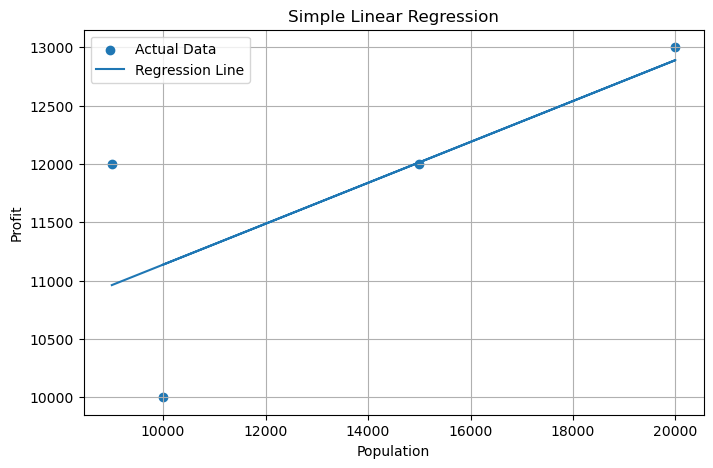


Predicted Profit for Population = 12000:
11487.012987012988


c:\Users\moksh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Remove the last row because it is the unseen data
train_df = df.iloc[:-1].copy()

# Population is the only input feature
X_simple = train_df[['Population']]
y = train_df['Profit']

# Create and train model
simple_model = LinearRegression()
simple_model.fit(X_simple, y)

# Predictions
y_pred_simple = simple_model.predict(X_simple)

# Coefficients
print("Simple Linear Regression")
print("------------------------")
print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_[0])

print(
    f"Equation: Profit = {simple_model.intercept_:.4f} "
    f"+ ({simple_model.coef_[0]:.4f} × Population)"
)

# Metrics
mse_simple = mean_squared_error(y, y_pred_simple)
mae_simple = mean_absolute_error(y, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y, y_pred_simple)

print("\nEvaluation Metrics:")
print("MSE :", mse_simple)
print("MAE :", mae_simple)
print("RMSE:", rmse_simple)
print("R²  :", r2_simple)

plt.figure(figsize=(8, 5))

plt.scatter(X_simple['Population'], y, label='Actual Data')
plt.plot(X_simple['Population'], y_pred_simple, label='Regression Line')

plt.xlabel("Population")
plt.ylabel("Profit")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

simple_prediction = simple_model.predict([[12000]])

print("\nPredicted Profit for Population = 12000:")
print(simple_prediction[0])

In [ ]:
from sklearn.linear_model import LinearRegression

X_multi = train[['Population', 'YearsInBusiness']].values
y_multi = train['Profit'].values

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)
print("Intercept:", model_multi.intercept_, "Coeffs:", model_multi.coef_)

Intercept: 7019.23076923077 Coeffs: [1.15384615e-01 5.76923077e+02]


In [ ]:
y_pred_multi = model_multi.predict(X_multi)

results = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R²'],
    'Simple LR': [mse, mae, rmse, r2],
    'Multi LR': [
        mean_squared_error(y_multi, y_pred_multi),
        mean_absolute_error(y_multi, y_pred_multi),
        np.sqrt(mean_squared_error(y_multi, y_pred_multi)),
        r2_score(y_multi, y_pred_multi)
    ]
})
results

,Metric,Simple LR,Multi LR
0,MSE,595779.220779,581730.769231
1,MAE,574.675325,634.615385
2,RMSE,771.867360,762.712770
3,R²,0.498291,0.510121


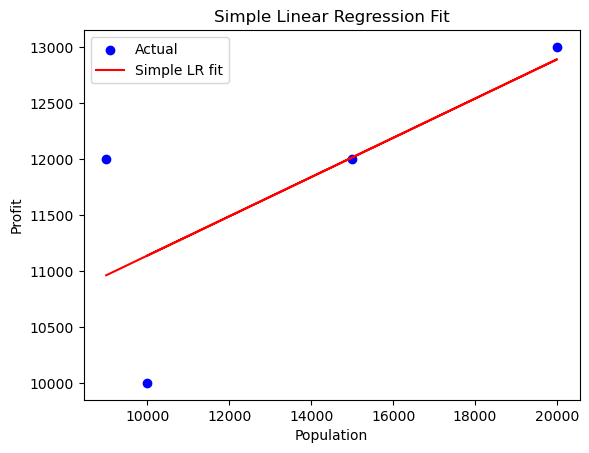

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred_simple, color='red', label='Simple LR fit')
plt.xlabel('Population'); plt.ylabel('Profit'); plt.legend()
plt.title('Simple Linear Regression Fit')
plt.savefig('simple_lr_plot.png')
plt.show()

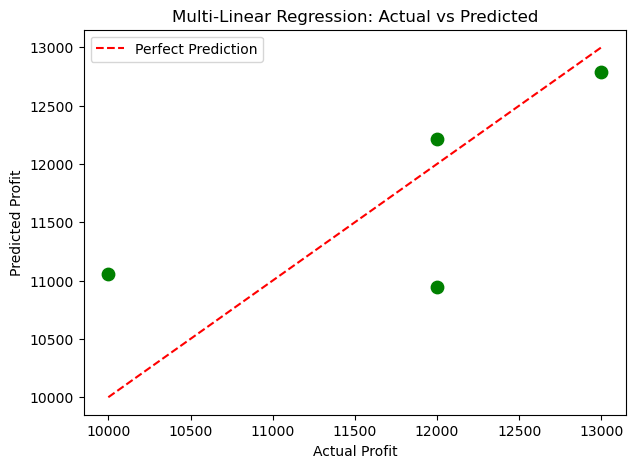

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_multi, y_pred_multi, color='green', s=80)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], 
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Multi-Linear Regression: Actual vs Predicted')
plt.legend()
plt.savefig('multi_lr_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
new_point = [[12000, 4]]
predicted_profit = model_multi.predict(new_point)
print("Predicted profit:", predicted_profit)

Predicted profit: [10711.53846154]
